## Mental Health In Tech Analysis

### Loading Data and Intial Exploration

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)
from sklearn.preprocessing import LabelEncoder

In [2]:
# Load Dataset
df = pd.read_csv('survey.csv')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Shape: 1259 rows, 27 columns


In [3]:
# Dataset First View - first 10 rows
df.head(10)

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN
5,2014-08-27 11:31:22,33,Male,United States,TN,NaN,Yes,No,Sometimes,6-25,No,Yes,Yes,Not sure,No,Don't know,Don't know,Don't know,No,No,Yes,Yes,No,Maybe,Don't know,No,NaN
6,2014-08-27 11:31:50,35,Female,United States,MI,NaN,Yes,Yes,Sometimes,1-5,Yes,Yes,No,No,No,No,No,Somewhat difficult,Maybe,Maybe,Some of them,No,No,No,Don't know,No,NaN
7,2014-08-27 11:32:05,39,M,Canada,NaN,NaN,No,No,Never,1-5,Yes,Yes,No,Yes,No,No,Yes,Don't know,No,No,No,No,No,No,No,No,NaN
8,2014-08-27 11:32:39,42,Female,United States,IL,NaN,Yes,Yes,Sometimes,100-500,No,Yes,Yes,Yes,No,No,No,Very difficult,Maybe,No,Yes,Yes,No,Maybe,No,No,NaN
9,2014-08-27 11:32:43,23,Male,Canada,NaN,NaN,No,No,Never,26-100,No,Yes,Don't know,No,Don't know,Don't know,Don't know,Don't know,No,No,Yes,Yes,Maybe,Maybe,Yes,No,NaN


In [4]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

In [5]:
# Missing values check
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
comments,1095,86.97
state,515,40.91
work_interfere,264,20.97
self_employed,18,1.43


In [6]:
# --- Clean Age ---
# Age has clearly invalid entries (negative values, and absurdly large values like 1e11)
print("Age range before cleaning:", df['Age'].min(), "to", df['Age'].max())
invalid_age_count = df[(df['Age'] < 18) | (df['Age'] > 100)].shape[0]
print(f"Invalid age rows (<18 or >100): {invalid_age_count}")

df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age'] = df['Age'].astype(int)
print("Age range after cleaning:", df['Age'].min(), "to", df['Age'].max())

Age range before cleaning: -1726 to 99999999999
Invalid age rows (<18 or >100): 8
Age range after cleaning: 18 to 72


In [7]:
# --- Clean Gender ---
# Consolidate 40+ free-text gender responses into Male / Female / Other
def clean_gender(g):
    g = str(g).strip().lower()
    male_terms = ['male', 'm', 'man', 'cis male', 'cis man', 'mail', 'malr', 'mal', 'maile',
                  'make', 'msle', 'male (cis)', 'male-ish', 'guy (-ish) ^_^', 'man ',
                  'male leaning androgynous', 'ostensibly male, unsure what that really means']
    female_terms = ['female', 'f', 'woman', 'cis female', 'cis-female/femme', 'femake',
                     'female (cis)', 'female (trans)', 'trans-female', 'trans woman',
                     'femail', 'woman ']
    if g in male_terms:
        return 'Male'
    elif g in female_terms:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)
print(df['Gender'].value_counts())

Gender
Male      994
Female    251
Other      14
Name: count, dtype: int64


In [8]:
# --- Handle missing / null values ---
# self_employed: small number of missing values -> impute with mode ('No', the majority class)
df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])

# work_interfere: NaN typically corresponds to respondents who have not sought treatment,
# so it is meaningful missingness, not random -> encode as its own category
df['work_interfere'] = df['work_interfere'].fillna('Not applicable')

# state: only meaningful for US respondents -> fill with 'Not in US' rather than dropping rows
df['state'] = df['state'].fillna('Not in US')

print(df[['self_employed', 'work_interfere', 'state']].isnull().sum())

self_employed     0
work_interfere    0
state             0
dtype: int64


In [9]:

# --- Drop irrelevant columns ---
# Timestamp is not needed for this analysis; comments is free text and mostly missing
df_clean = df.drop(columns=['Timestamp', 'comments'])
print("Columns remaining:", df_clean.shape[1])
df_clean.head()

Columns remaining: 25


,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Female,United States,IL,No,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,Male,United States,IN,No,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,Male,Canada,Not in US,No,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31,Male,United Kingdom,Not in US,No,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31,Male,United States,TX,No,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


## Univariate analysis

### Demographic Overview 

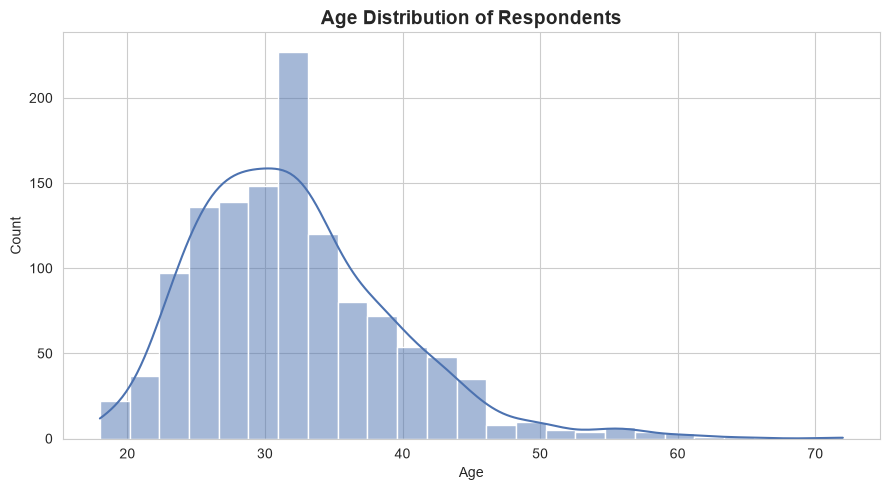

count    1259.000000
mean       32.069897
std         7.265565
min        18.000000
25%        27.000000
50%        31.000000
75%        36.000000
max        72.000000
Name: Age, dtype: float64


In [10]:
# Age distribution
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df_clean['Age'], bins=25, kde=True, color='#4C72B0', ax=ax)
ax.set_title('Age Distribution of Respondents', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(df_clean['Age'].describe())

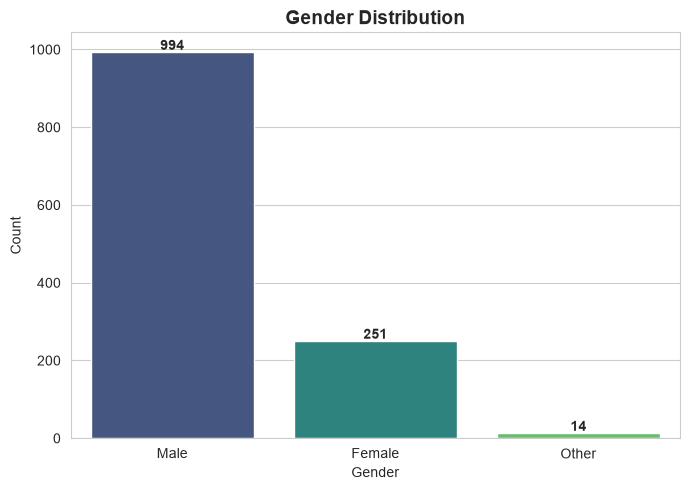

Gender
Male      79.0
Female    19.9
Other      1.1
Name: count, dtype: float64


In [11]:
# Gender distribution
fig, ax = plt.subplots(figsize=(7, 5))
gender_counts = df_clean['Gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, hue=gender_counts.index,
            palette='viridis', legend=False, ax=ax)
ax.set_title('Gender Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print((gender_counts / len(df_clean) * 100).round(1))

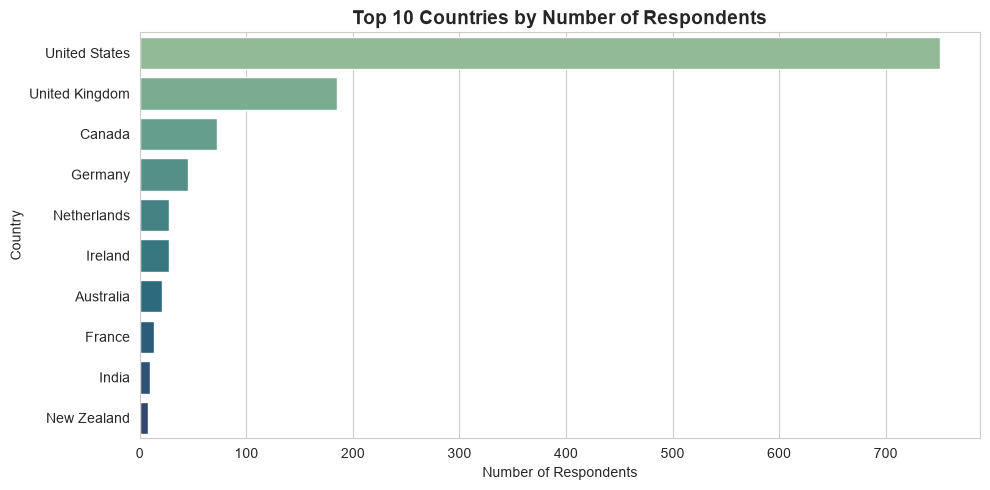

Country
United States     751
United Kingdom    185
Canada             72
Germany            45
Netherlands        27
Ireland            27
Australia          21
France             13
India              10
New Zealand         8
Name: count, dtype: int64

In [12]:
# Country-wise response count (top 10)
top_countries = df_clean['Country'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index,
            palette='crest', legend=False, ax=ax)
ax.set_title('Top 10 Countries by Number of Respondents', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Respondents')
ax.set_ylabel('Country')
plt.tight_layout()
plt.show()

top_countries

### Mental Health Context

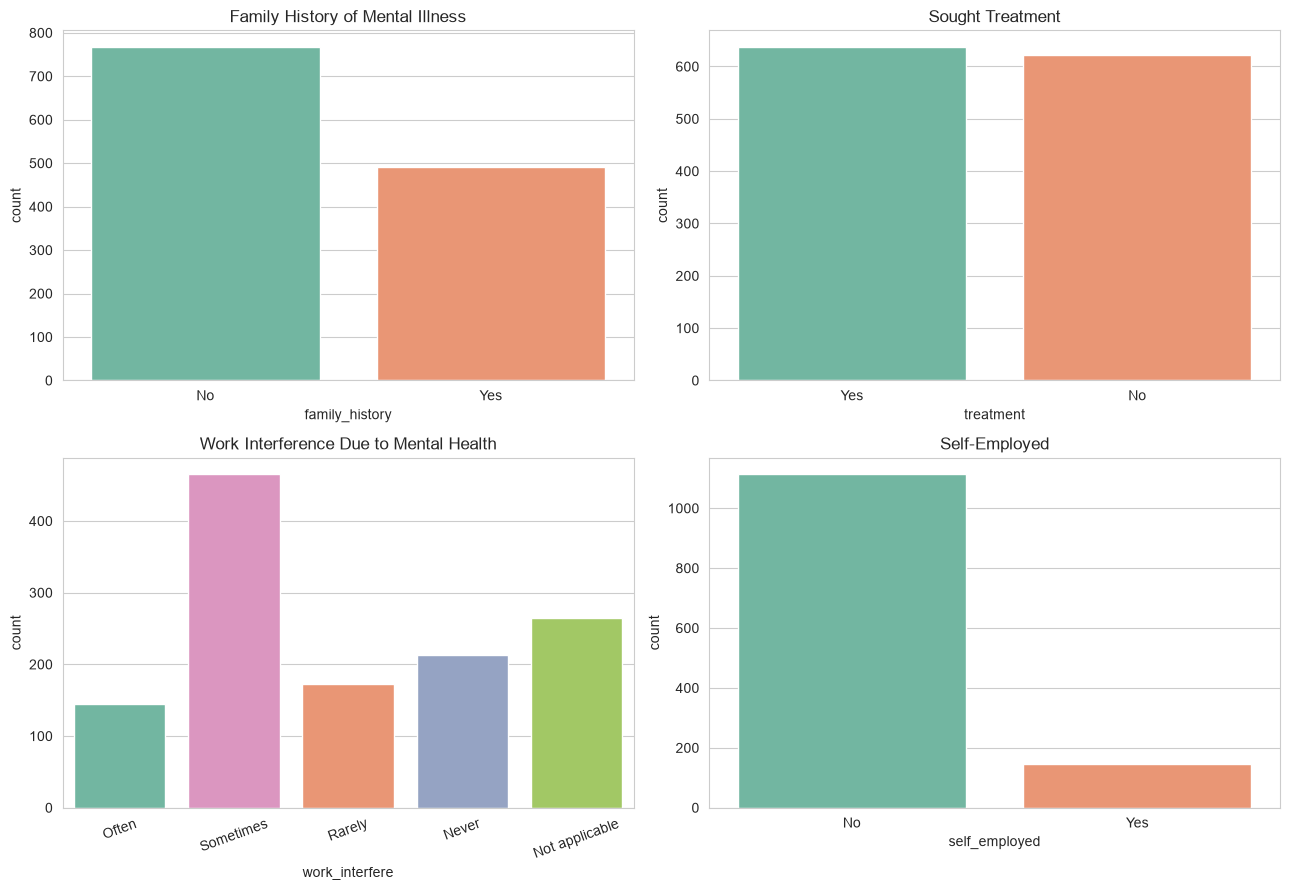


family_history:
family_history
No     767
Yes    492
Name: count, dtype: int64

treatment:
treatment
Yes    637
No     622
Name: count, dtype: int64

work_interfere:
work_interfere
Sometimes         465
Not applicable    264
Never             213
Rarely            173
Often             144
Name: count, dtype: int64

self_employed:
self_employed
No     1113
Yes     146
Name: count, dtype: int64


In [13]:
# Counts of family history, treatment, work interference, self-employment
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.countplot(data=df_clean, x='family_history', hue='family_history', palette='Set2',
              legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Family History of Mental Illness')

sns.countplot(data=df_clean, x='treatment', hue='treatment', palette='Set2',
              legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Sought Treatment')

order = ['Often', 'Sometimes', 'Rarely', 'Never', 'Not applicable']
sns.countplot(data=df_clean, x='work_interfere', hue='work_interfere', order=order,
              palette='Set2', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Work Interference Due to Mental Health')
axes[1, 0].tick_params(axis='x', rotation=20)

sns.countplot(data=df_clean, x='self_employed', hue='self_employed', palette='Set2',
              legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Self-Employed')

plt.tight_layout()
plt.show()

for col in ['family_history', 'treatment', 'work_interfere', 'self_employed']:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())

*** Insghts ***

## Bivariate Analysis

### Gender & Treatment

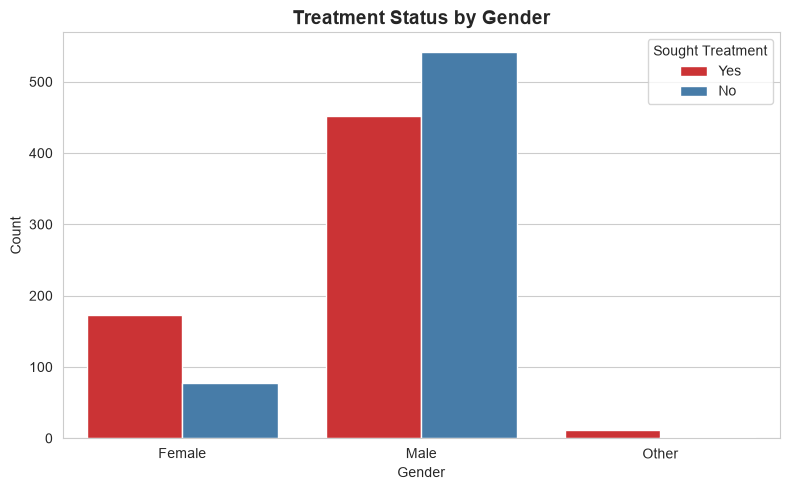

treatment,No,Yes
Gender,,
Female,31.1,68.9
Male,54.5,45.5
Other,14.3,85.7


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_clean, x='Gender', hue='treatment', palette='Set1', ax=ax)
ax.set_title('Treatment Status by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Count')
ax.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()

treatment_by_gender = pd.crosstab(df_clean['Gender'], df_clean['treatment'], normalize='index') * 100
treatment_by_gender.round(1)

### Country & Work Interference

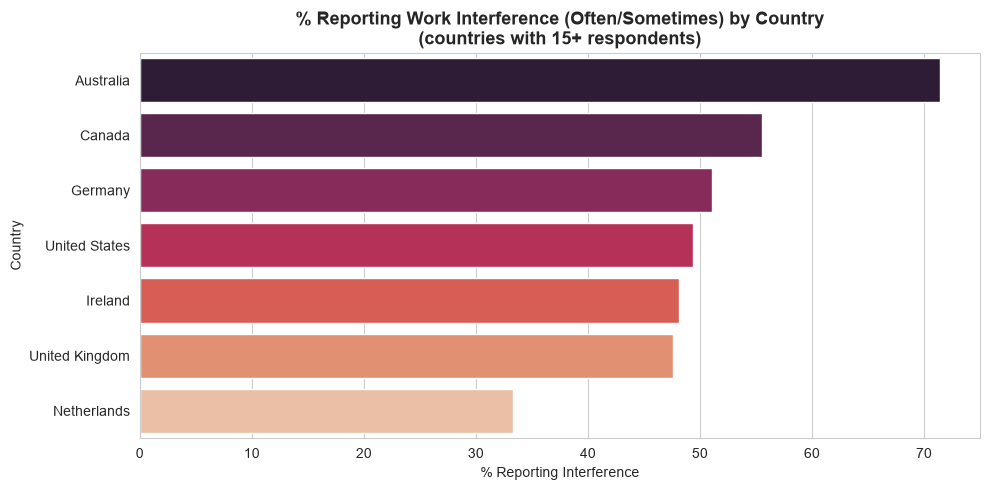

Country
Australia         71.4
Canada            55.6
Germany           51.1
United States     49.4
Ireland           48.1
United Kingdom    47.6
Netherlands       33.3
Name: interferes_flag, dtype: float64

In [15]:
# % of respondents whose mental health interferes with work (Often/Sometimes), by country
# restricted to countries with a reasonable sample size for a meaningful percentage
interferes = df_clean['work_interfere'].isin(['Often', 'Sometimes'])
df_clean['interferes_flag'] = interferes

country_counts = df_clean['Country'].value_counts()
valid_countries = country_counts[country_counts >= 15].index

country_interfere_pct = (df_clean[df_clean['Country'].isin(valid_countries)]
                          .groupby('Country')['interferes_flag']
                          .mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=country_interfere_pct.values, y=country_interfere_pct.index,
            hue=country_interfere_pct.index, palette='rocket', legend=False, ax=ax)
ax.set_title('% Reporting Work Interference (Often/Sometimes) by Country\n(countries with 15+ respondents)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('% Reporting Interference')
plt.tight_layout()
plt.show()

country_interfere_pct.round(1)

### Company Size & Benefits

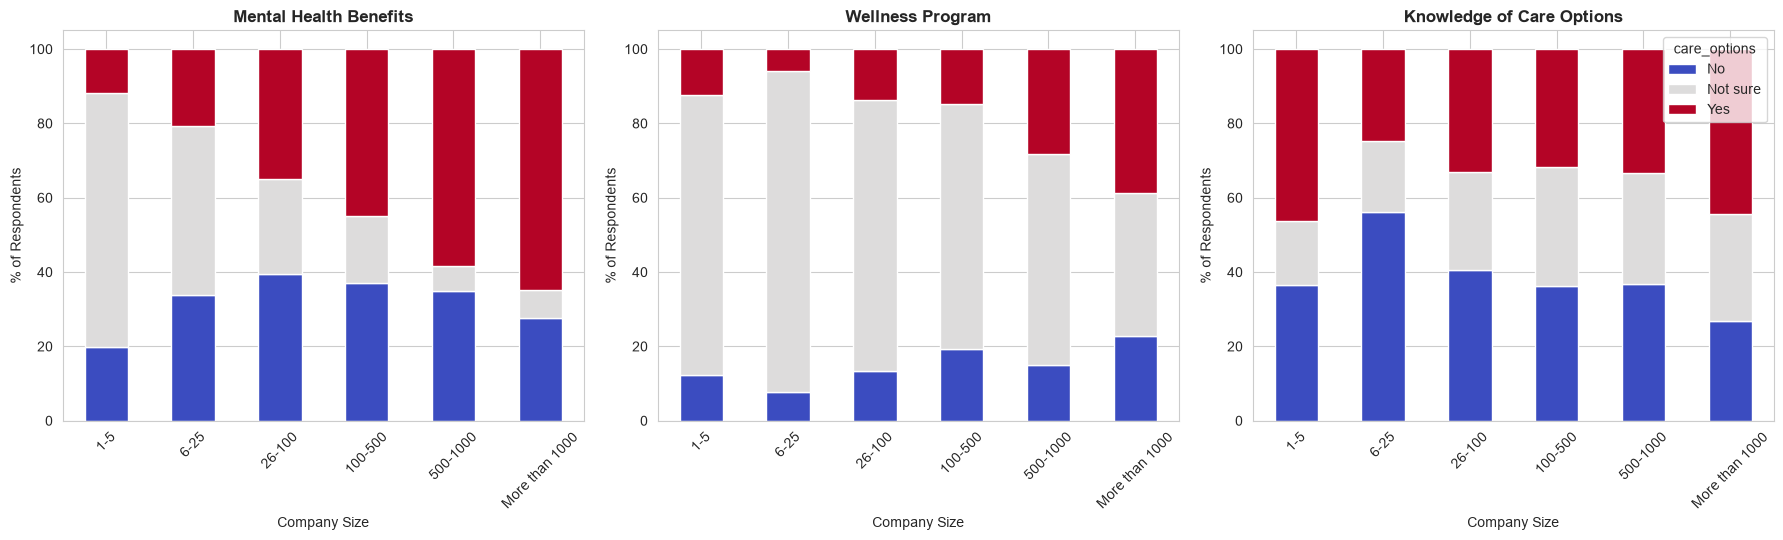

In [16]:
order_size = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, col, title in zip(
    axes,
    ['benefits', 'wellness_program', 'care_options'],
    ['Mental Health Benefits', 'Wellness Program', 'Knowledge of Care Options']
):
    ct = pd.crosstab(df_clean['no_employees'], df_clean[col], normalize='index').reindex(order_size) * 100
    ct.plot(kind='bar', stacked=True, colormap='coolwarm', ax=ax, legend=(ax == axes[2]))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Company Size')
    ax.set_ylabel('% of Respondents')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

*** Insights ***

## Attitude Towards Mental Health

### Discussion Comfort 

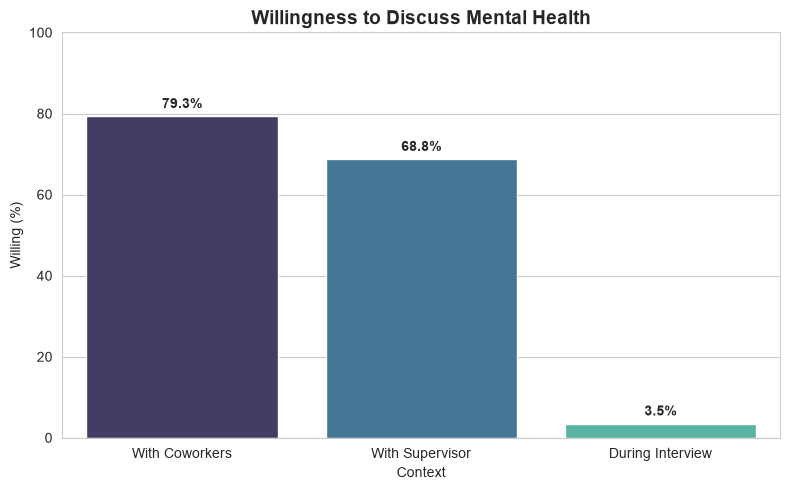

,Context,Willing (%)
0,With Coworkers,79.348689
1,With Supervisor,68.784750
2,During Interview,3.494837


In [17]:
# % willing to discuss mental health with coworkers, supervisors, and during interviews
coworker_pct = (df_clean['coworkers'].isin(['Yes', 'Some of them']).mean() * 100)
supervisor_pct = (df_clean['supervisor'].isin(['Yes', 'Some of them']).mean() * 100)
interview_pct = (df_clean['mental_health_interview'] == 'Yes').mean() * 100

comfort_df = pd.DataFrame({
    'Context': ['With Coworkers', 'With Supervisor', 'During Interview'],
    'Willing (%)': [coworker_pct, supervisor_pct, interview_pct]
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=comfort_df, x='Context', y='Willing (%)', hue='Context', palette='mako',
            legend=False, ax=ax)
ax.set_title('Willingness to Discuss Mental Health', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
for i, v in enumerate(comfort_df['Willing (%)']):
    ax.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

comfort_df

*** Insights ***

### Mental vs Physical Health Perceptions

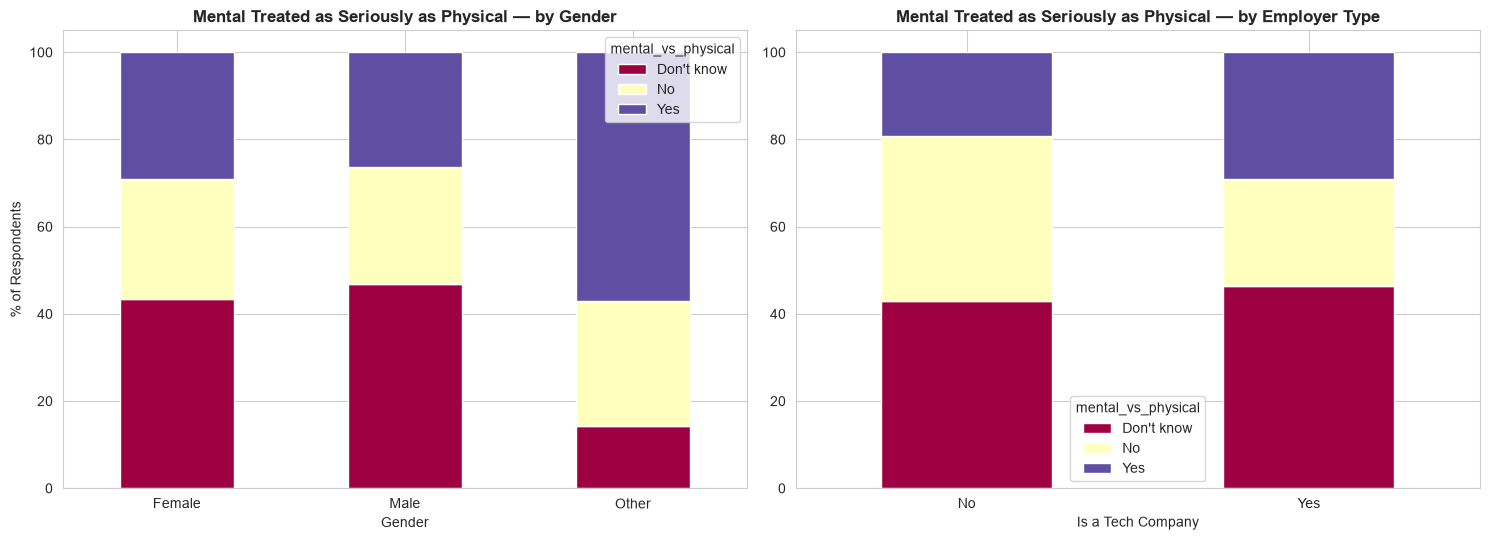

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

mvp_gender = pd.crosstab(df_clean['Gender'], df_clean['mental_vs_physical'], normalize='index') * 100
mvp_gender.plot(kind='bar', stacked=True, colormap='Spectral', ax=axes[0])
axes[0].set_title('Mental Treated as Seriously as Physical — by Gender', fontweight='bold')
axes[0].set_ylabel('% of Respondents')
axes[0].tick_params(axis='x', rotation=0)

mvp_tech = pd.crosstab(df_clean['tech_company'], df_clean['mental_vs_physical'], normalize='index') * 100
mvp_tech.plot(kind='bar', stacked=True, colormap='Spectral', ax=axes[1])
axes[1].set_title('Mental Treated as Seriously as Physical — by Employer Type', fontweight='bold')
axes[1].set_xlabel('Is a Tech Company')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Anonymity & Consequences

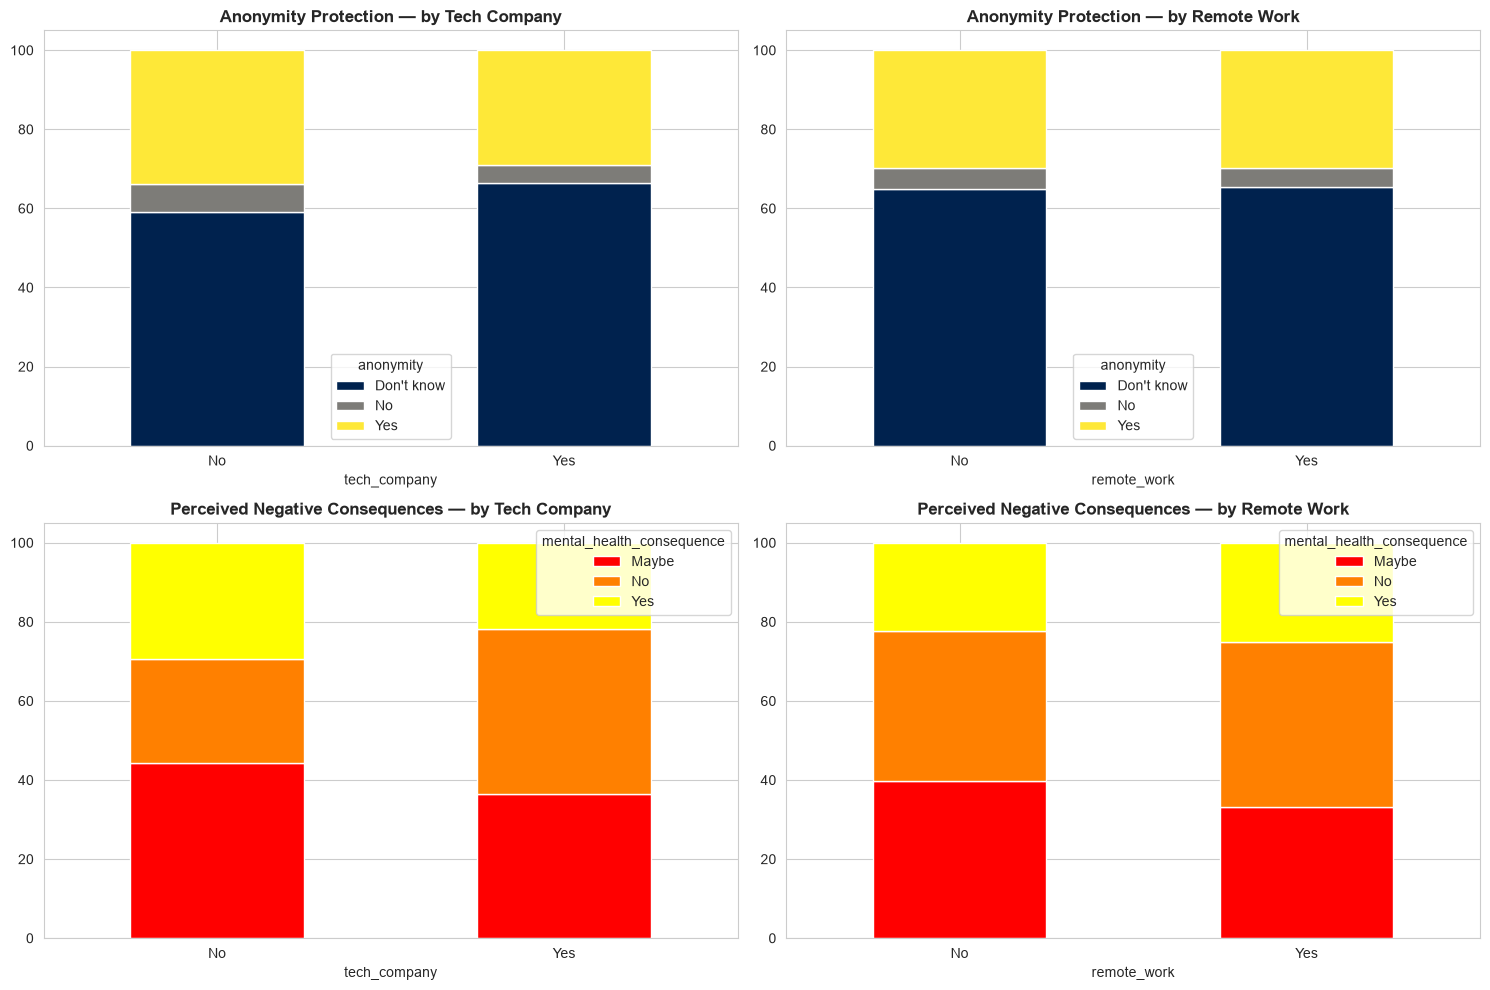

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

pd.crosstab(df_clean['tech_company'], df_clean['anonymity'], normalize='index').mul(100)\
    .plot(kind='bar', stacked=True, colormap='cividis', ax=axes[0, 0])
axes[0, 0].set_title('Anonymity Protection — by Tech Company', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=0)

pd.crosstab(df_clean['remote_work'], df_clean['anonymity'], normalize='index').mul(100)\
    .plot(kind='bar', stacked=True, colormap='cividis', ax=axes[0, 1])
axes[0, 1].set_title('Anonymity Protection — by Remote Work', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=0)

pd.crosstab(df_clean['tech_company'], df_clean['mental_health_consequence'], normalize='index').mul(100)\
    .plot(kind='bar', stacked=True, colormap='autumn', ax=axes[1, 0])
axes[1, 0].set_title('Perceived Negative Consequences — by Tech Company', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=0)

pd.crosstab(df_clean['remote_work'], df_clean['mental_health_consequence'], normalize='index').mul(100)\
    .plot(kind='bar', stacked=True, colormap='autumn', ax=axes[1, 1])
axes[1, 1].set_title('Perceived Negative Consequences — by Remote Work', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

*** Insights ***

## Geographic & Remote Work Insights

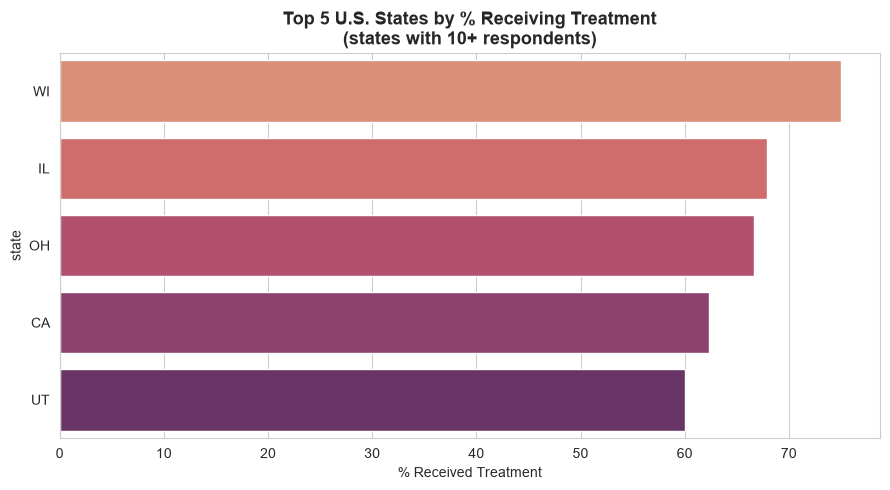

state
WI    75.0
IL    67.9
OH    66.7
CA    62.3
UT    60.0
Name: treatment, dtype: float64

In [20]:
us_df = df_clean[df_clean['Country'] == 'United States']
us_df = us_df[us_df['state'] != 'Not in US']

state_counts = us_df['state'].value_counts()
valid_states = state_counts[state_counts >= 10].index  # ensure a meaningful sample per state

state_treatment_pct = (us_df[us_df['state'].isin(valid_states)]
                        .groupby('state')['treatment']
                        .apply(lambda s: (s == 'Yes').mean() * 100)
                        .sort_values(ascending=False))

top5_states = state_treatment_pct.head(5)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top5_states.values, y=top5_states.index, hue=top5_states.index,
            palette='flare', legend=False, ax=ax)
ax.set_title('Top 5 U.S. States by % Receiving Treatment\n(states with 10+ respondents)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('% Received Treatment')
plt.tight_layout()
plt.show()

top5_states.round(1)

###  Remote Work Effect

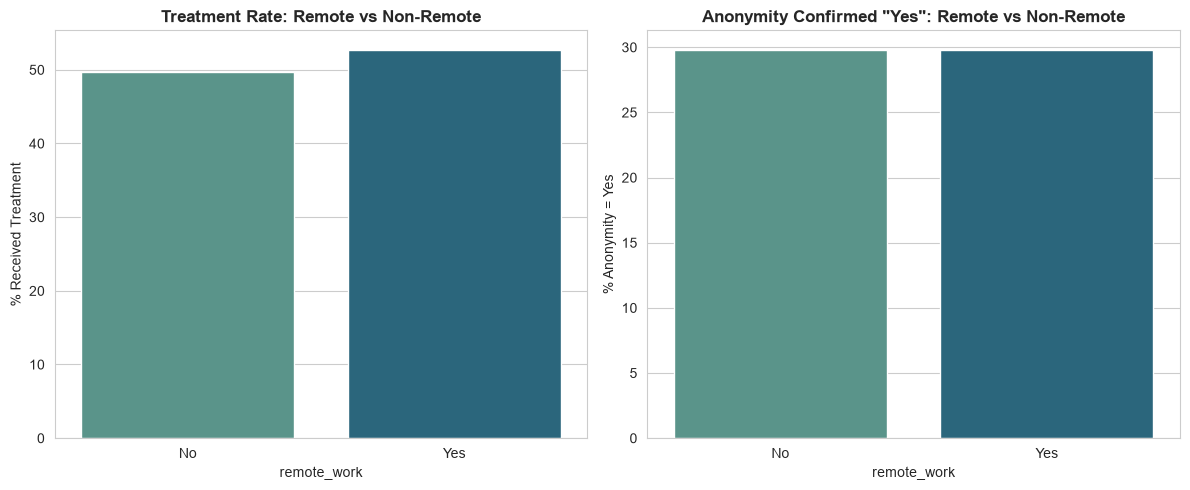

,treatment_rate_pct,anonymity_known_pct
remote_work,,
No,49.7,29.8
Yes,52.7,29.8


In [21]:
remote_compare = df_clean.groupby('remote_work').agg(
    treatment_rate_pct=('treatment', lambda s: (s == 'Yes').mean() * 100),
    anonymity_known_pct=('anonymity', lambda s: (s == 'Yes').mean() * 100)
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=remote_compare.index, y=remote_compare['treatment_rate_pct'], hue=remote_compare.index,
            palette='crest', legend=False, ax=axes[0])
axes[0].set_title('Treatment Rate: Remote vs Non-Remote', fontweight='bold')
axes[0].set_ylabel('% Received Treatment')

sns.barplot(x=remote_compare.index, y=remote_compare['anonymity_known_pct'], hue=remote_compare.index,
            palette='crest', legend=False, ax=axes[1])
axes[1].set_title('Anonymity Confirmed "Yes": Remote vs Non-Remote', fontweight='bold')
axes[1].set_ylabel('% Anonymity = Yes')

plt.tight_layout()
plt.show()

remote_compare

*** Insights ***

## Predictive Insights

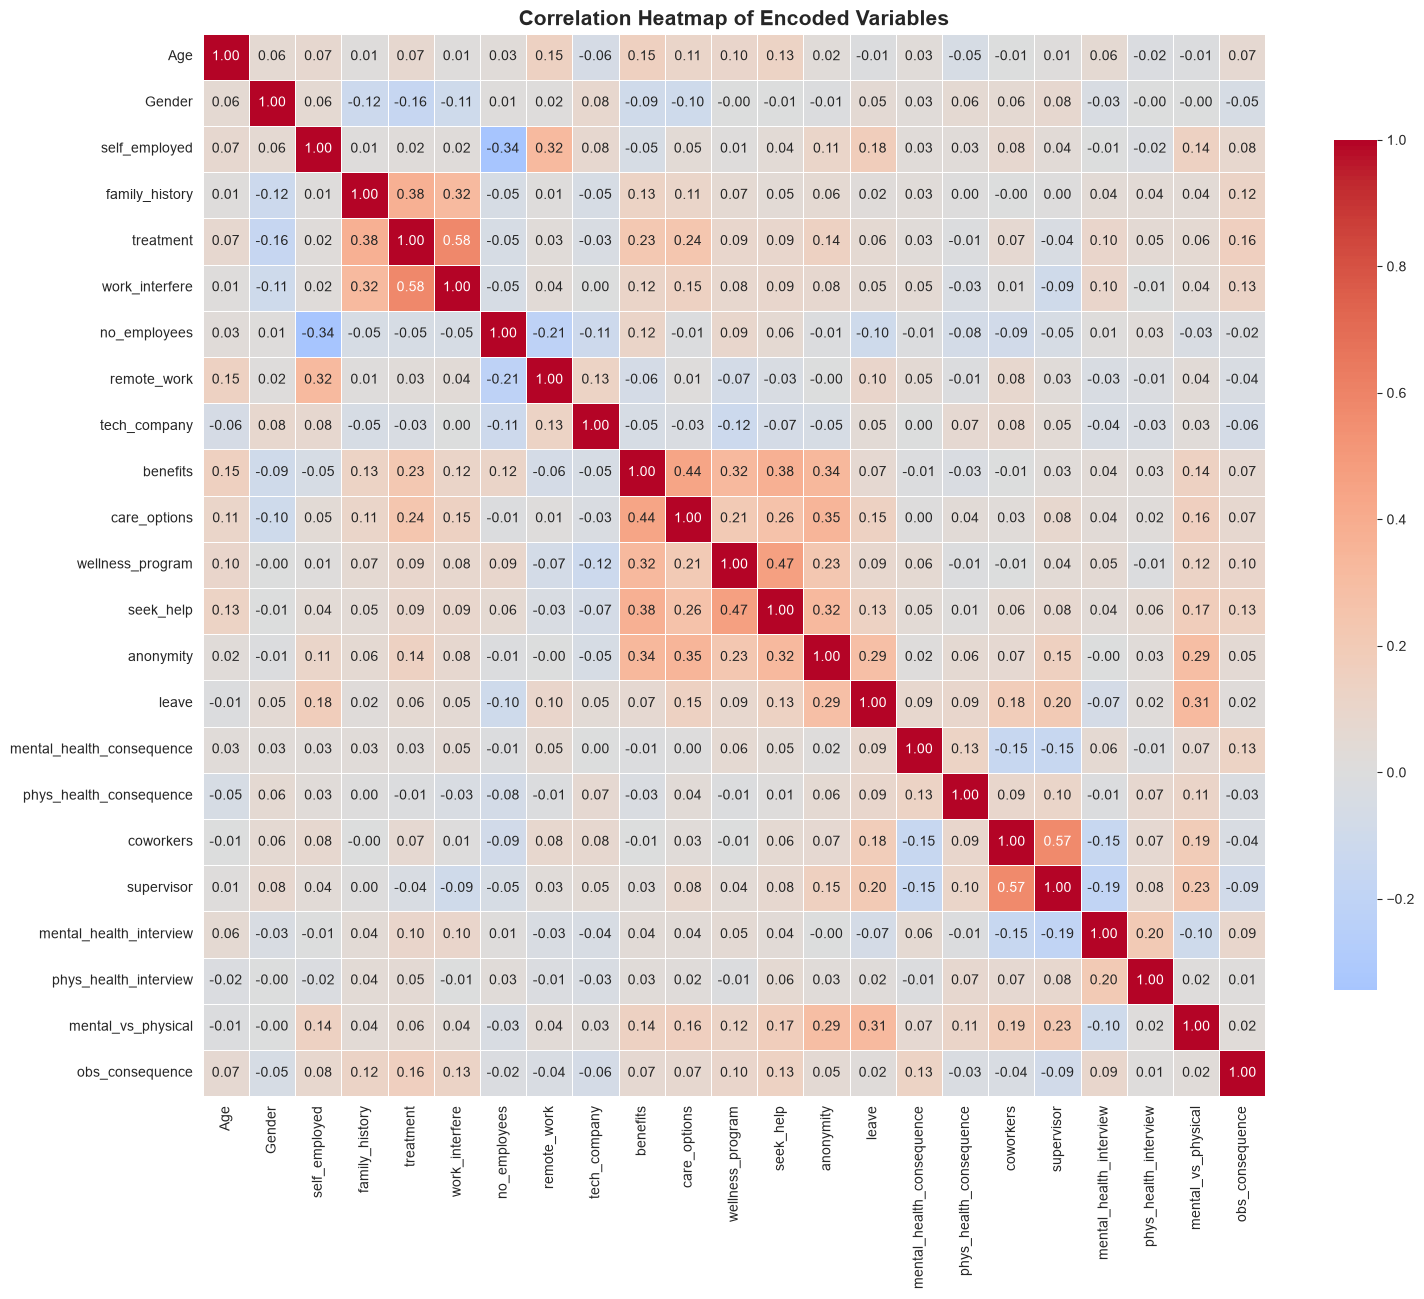

In [22]:
encode_cols = ['Gender', 'self_employed', 'family_history', 'treatment', 'work_interfere',
               'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options',
               'wellness_program', 'seek_help', 'anonymity', 'leave',
               'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor',
               'mental_health_interview', 'phys_health_interview', 'mental_vs_physical',
               'obs_consequence']

df_encoded = df_clean.copy()
encoders = {}
for col in encode_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le

corr_cols = ['Age'] + encode_cols
corr_matrix = df_encoded[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap of Encoded Variables', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# Variables most correlated with 'treatment'
treatment_corr = corr_matrix['treatment'].drop('treatment').sort_values(key=abs, ascending=False)
treatment_corr.head(10)

work_interfere             0.580216
family_history             0.377918
care_options               0.236578
benefits                   0.226140
obs_consequence            0.156972
Gender                    -0.156017
anonymity                  0.142889
mental_health_interview    0.098413
wellness_program           0.094713
seek_help                  0.089935
Name: treatment, dtype: float64

## Logistic Regression 

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

feature_cols = ['Age', 'Gender', 'self_employed', 'family_history', 'work_interfere',
                 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options',
                 'wellness_program', 'seek_help', 'anonymity', 'leave',
                 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor',
                 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical',
                 'obs_consequence']

X = df_encoded[feature_cols]
y = df_encoded['treatment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, target_names=['No Treatment', 'Treatment']))

Accuracy: 0.794

              precision    recall  f1-score   support

No Treatment       0.78      0.81      0.79       124
   Treatment       0.81      0.78      0.79       128

    accuracy                           0.79       252
   macro avg       0.79      0.79      0.79       252
weighted avg       0.79      0.79      0.79       252

